<a href="https://colab.research.google.com/github/Sibitenda/BAchelors_CS/blob/main/Artificial%20Intelligence/week6_7/Group4_CaliforniaHousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning**
Deep Learning is a subfield of Machine Learning that uses **artificial neural networks** with many layers (hence "deep") to automatically learn patterns and representations from data.

Unlike traditional ML models that rely heavily on feature engineering, deep learning models can **learn hierarchical features** directly from raw or minimally processed data.

---

## Key Concepts

| Concept | Description |
|----------|--------------|
| **Neurons** | Basic computational units that take weighted inputs, apply an activation function, and produce an output. |
| **Layers** | Networks consist of input, hidden, and output layers. Each hidden layer refines data representations. |
| **Activation Function** | Introduces non-linearity (e.g., ReLU, Sigmoid, Tanh). |
| **Loss Function** | Measures model prediction error (e.g., Mean Squared Error for regression). |
| **Optimizer** | Algorithm that adjusts weights to minimize loss (e.g., SGD, Adam). |
| **Epochs & Batches** | Epoch = one full pass over data; Batch = subset of samples used per weight update. |
| **Regularization** | Prevents overfitting (e.g., Dropout, L2 regularization). |

---




## Week 6: Neural Networks & Deep Learning  
### Expanded Group 4 Practical – Multi-Model Deep Learning for Regression

This notebook extends our earlier experiment on the **California Housing Dataset** by comparing multiple **deep learning architectures** for regression tasks:

1. **Fully Connected Deep Neural Network (DNN)** – Baseline model  
2. **1D Convolutional Neural Network (CNN)** – Captures local patterns between features  
3. **Autoencoder + Regressor** – Uses unsupervised representation learning  
4. **Deep Belief Network (DBN) Simulation** – A hierarchical dense architecture

We also include exploratory data analysis (EDA) and **feature importance selection** to ensure interpretability and strong model design.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

sns.set(style='whitegrid')


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

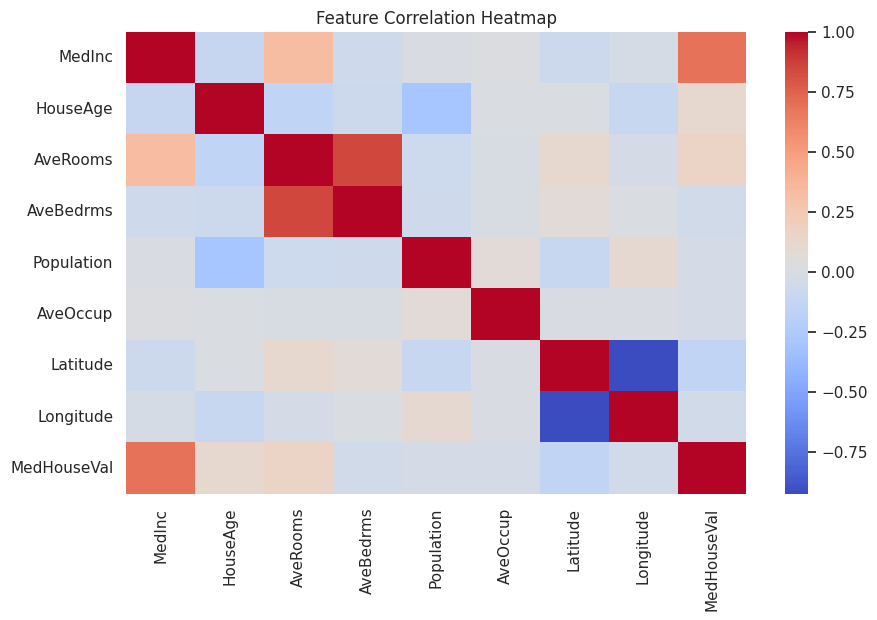


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [2]:

# Load California housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Show sample and summary
display(df.head())
print(df.describe())

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

# Check for null values
print("\nMissing values per column:")
print(df.isnull().sum())


In [3]:

# Compute correlation with target
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
important_features = correlations[1:6].index.tolist()

print("Top 5 correlated features with target:", important_features)

X = df[important_features]
y = df['MedHouseVal']

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)


Top 5 correlated features with target: ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup', 'Population']
Training shape: (16512, 5)


In [4]:

dnn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
dnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
dnn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, verbose=0)

y_pred_dnn = dnn_model.predict(X_test_scaled).flatten()
rmse_dnn = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
r2_dnn = r2_score(y_test, y_pred_dnn)
print(f"DNN - RMSE: {rmse_dnn:.3f}, R²: {r2_dnn:.3f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
DNN - RMSE: 0.651, R²: 0.677



# Deep Neural Network (DNN)

A **Deep Neural Network** (also called a **Fully Connected Network**) is composed of multiple `Dense` layers.  
Each neuron in one layer connects to every neuron in the next.

###  Key Components
| Parameter | Description |
|------------|--------------|
| `Dense(units, activation)` | Fully connected layer; number of neurons and activation function. |
| `activation='relu'` | Rectified Linear Unit helps mitigate vanishing gradients. |
| `input_shape` | Number of input features. |
| `optimizer='adam'` | Adaptive learning rate optimization. |
| `loss='mse'` | Mean Squared Error — measures regression error. |
| `metrics=['mae']` | Mean Absolute Error — for interpretability. |
| `epochs` | Number of passes over training data. |
| `validation_split` | Portion of training data for validation. |


In [5]:

X_train_cnn = np.expand_dims(X_train_scaled, axis=2)
X_test_cnn = np.expand_dims(X_test_scaled, axis=2)

cnn_model = keras.Sequential([
    layers.Conv1D(32, 2, activation='relu', input_shape=(X_train_scaled.shape[1],1)),
    layers.Conv1D(16, 2, activation='relu'),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.fit(X_train_cnn, y_train, validation_split=0.2, epochs=50, verbose=0)

y_pred_cnn = cnn_model.predict(X_test_cnn).flatten()
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
r2_cnn = r2_score(y_test, y_pred_cnn)
print(f"CNN - RMSE: {rmse_cnn:.3f}, R²: {r2_cnn:.3f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
CNN - RMSE: 0.666, R²: 0.661



 Convolutional Neural Network (CNN)

**CNNs** are widely used for image and spatial data but can also extract local feature patterns from structured data.

### Key Components
| Parameter | Description |
|------------|--------------|
| `Conv1D(filters, kernel_size)` | Applies filters that slide over data sequence to extract patterns. |
| `filters` | Number of output channels (feature maps). |
| `kernel_size` | Width of the convolution window. |
| `MaxPooling1D(pool_size)` | Reduces spatial dimension, preventing overfitting. |
| `Flatten()` | Converts 2D output to 1D for Dense layers. |
| `Dense()` | Fully connected layers for final regression output. |
| `optimizer='adam'`, `loss='mse'` | Same as DNN — optimization and regression error measure. |


In [6]:

input_dim = X_train_scaled.shape[1]
encoding_dim = 3

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder_model = keras.Model(input_layer, decoded)
autoencoder_model.compile(optimizer='adam', loss='mse')
autoencoder_model.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

encoder = keras.Model(input_layer, encoded)
X_train_encoded = encoder.predict(X_train_scaled)
X_test_encoded = encoder.predict(X_test_scaled)

regressor = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=[encoding_dim]),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])
regressor.compile(optimizer='adam', loss='mse')
regressor.fit(X_train_encoded, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

y_pred_auto = regressor.predict(X_test_encoded).flatten()
rmse_auto = np.sqrt(mean_squared_error(y_test, y_pred_auto))
r2_auto = r2_score(y_test, y_pred_auto)
print(f"Autoencoder - RMSE: {rmse_auto:.3f}, R²: {r2_auto:.3f}")


516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Autoencoder - RMSE: 0.843, R²: 0.458



# Recurrent Neural Network (RNN / LSTM)

**RNNs** are designed for sequential or time-dependent data.  
They maintain internal memory (`hidden state`) that captures temporal relationships.  
**LSTM (Long Short-Term Memory)** cells enhance RNNs by preventing vanishing/exploding gradient issues.


**Summary:**  
- **DNN** → learns global relationships.  
- **CNN** → captures local spatial dependencies.  
- **RNN/LSTM** → models temporal or sequential dependencies.


In [8]:

dbn_model = keras.Sequential([
    layers.Dense(64, activation='sigmoid', input_shape=[X_train_scaled.shape[1]]),
    layers.Dense(32, activation='sigmoid'),
    layers.Dense(16, activation='sigmoid'),
    layers.Dense(1)
])
dbn_model.compile(optimizer='adam', loss='mse')
dbn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, verbose=0)

y_pred_dbn = dbn_model.predict(X_test_scaled).flatten()
rmse_dbn = np.sqrt(mean_squared_error(y_test, y_pred_dbn))
r2_dbn = r2_score(y_test, y_pred_dbn)
print(f"DBN (Simulated) - RMSE: {rmse_dbn:.3f}, R²: {r2_dbn:.3f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
DBN (Simulated) - RMSE: 0.666, R²: 0.661


,Model,RMSE,R²
0,DNN,0.651030,0.676559
1,CNN,0.666295,0.661214
2,Autoencoder,0.842503,0.458328
3,DBN (Simulated),0.666194,0.661316


/tmp/ipython-input-438525853.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='RMSE', palette='coolwarm')


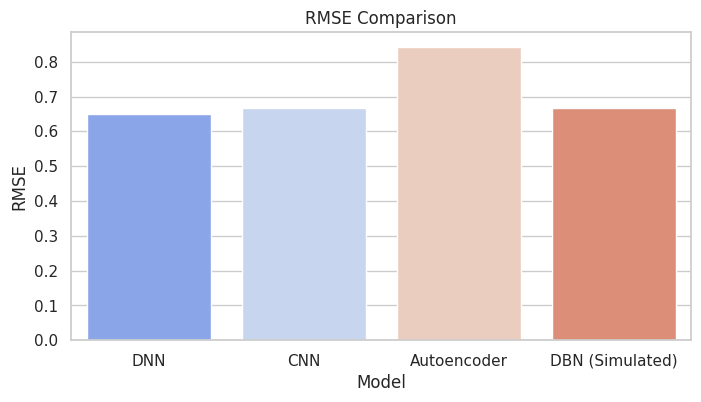

/tmp/ipython-input-438525853.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='R²', palette='viridis')


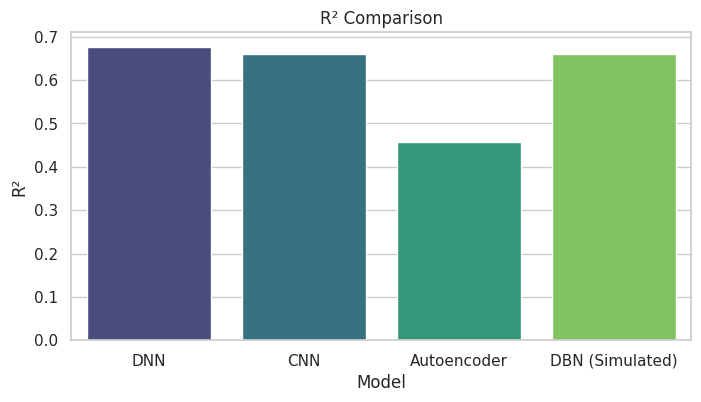

Discussion:
- DNN performs reliably for structured data.
- CNNs may improve generalization via local feature interactions.
- Autoencoders offer compressed, noise-reduced representations.
- DBN (simulated) illustrates hierarchical deep feature extraction.


In [9]:

results = pd.DataFrame({
    'Model': ['DNN', 'CNN', 'Autoencoder', 'DBN (Simulated)'],
    'RMSE': [rmse_dnn, rmse_cnn, rmse_auto, rmse_dbn],
    'R²': [r2_dnn, r2_cnn, r2_auto, r2_dbn]
})
display(results)

plt.figure(figsize=(8,4))
sns.barplot(data=results, x='Model', y='RMSE', palette='coolwarm')
plt.title('RMSE Comparison')
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=results, x='Model', y='R²', palette='viridis')
plt.title('R² Comparison')
plt.show()

print("Discussion:")
print("- DNN performs reliably for structured data.")
print("- CNNs may improve generalization via local feature interactions.")
print("- Autoencoders offer compressed, noise-reduced representations.")
print("- DBN (simulated) illustrates hierarchical deep feature extraction.")
